# Credit Card Fraud Detection By Using Machine Learning

### Life cycle of Machine learning Project
Understanding the Problem Statement
Data Collection
Data Checks to perform
Exploratory data analysis
Data Pre-Processing
Model Training
Choose best model

 1) *Problem statement*

Financial institutions and online payment systems face significant losses due to fraudulent credit card transactions. With the rapid growth of digital payments, detecting unauthorized and fraudulent activities has become a major challenge. Traditional rule-based systems are often unable to identify new and complex fraud patterns efficiently.

 2) *Data Collection*

Dataset Source - www.kaggle.com
The Traning data consists of 23 column and 1296675 rows.
The Testing data consists of 23 column and 555719 rows.

2.1 Import Data and Required Packages

Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

Import the CSV Data as Pandas DataFrame

In [50]:
DataFrame_1=pd.read_csv("fraudTrain.csv")
DataFrame_2=pd.read_csv("fraudTest.csv")

Show Top 5 Records

In [51]:
#DataFrame_1 is a traning dataset
DataFrame_1.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [52]:
#DataFrame_2 is a testing dataset
DataFrame_2.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


Shape of the dataset

In [38]:
#Traning Data
DataFrame_1.shape

(1296675, 23)

In [39]:
#Testing Data
DataFrame_2.shape

(555719, 23)

2.2 Dataset information

Column Name            Description                              

`Unnamed: 0`          Index column automatically created while saving CSV 
`trans_date_trans_time`Date and time of transaction                
`cc_num`              Credit card number                              
`merchant`            Merchant/shop name where transaction happened       
`category`            Transaction category (shopping, grocery, gas, etc.) 
`amt`                 Transaction amount                             
`first`               Customer first name                          
`last`                Customer last name                     
`gender`              Gender of customer                            
`street`              Customer street address                
`city`                Customer city                              
`state`               Customer state                                     
`zip`                 ZIP/postal code                          
`lat`                 Customer latitude                    
`long`                Customer longitude                                  
`city_pop`            Population of customer city    
`job`                 Customer occupation                                 
`dob`                 Date of birth                                       
`trans_num`           Unique transaction ID                               
`unix_time`           Transaction timestamp in Unix format               
`merch_lat`           Merchant latitude                        
`merch_long`          Merchant longitude           
`is_fraud`            Target column →`1 = Fraud`,`0 = Not Fraud`        


3. Data Checks to perform

Check Missing values
Check Duplicates
Check data type
Check the number of unique values of each column
Check statistics of data set
Check various categories present in the different categorical column

3.1 Check Missing values

In [ ]:
#Traning Data
print('DataFrame_1_missing_Values :',DataFrame_1.isnull().sum())

DataFrame_1_missing_Values : Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64


In [16]:
#Testing Data
print('DataFrame_2_missing_Values :',DataFrame_2.isnull().sum())

DataFrame_2_missing_Values : Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64


# There are no missing values in the data set

3.2 Check Duplicates

In [17]:
#Traning Data
DataFrame_1.duplicated().sum()

0

In [18]:
#Testing Data
DataFrame_2.duplicated().sum()

0

# There are no duplicates values in the Traning and Testing data set

3.3 Check data types

# Check Null and Dtypes

In [19]:
#Traning Data
DataFrame_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [20]:
#Testing Data
DataFrame_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

3.4 Checking the number of unique values of each column

In [21]:
#Traning Data
DataFrame_1.nunique()

Unnamed: 0               1296675
trans_date_trans_time    1274791
cc_num                       983
merchant                     693
category                      14
amt                        52928
first                        352
last                         481
gender                         2
street                       983
city                         894
state                         51
zip                          970
lat                          968
long                         969
city_pop                     879
job                          494
dob                          968
trans_num                1296675
unix_time                1274823
merch_lat                1247805
merch_long               1275745
is_fraud                       2
dtype: int64

In [22]:
#Testing Data
DataFrame_2.nunique()

Unnamed: 0               555719
trans_date_trans_time    544760
cc_num                      924
merchant                    693
category                     14
amt                       37256
first                       341
last                        471
gender                        2
street                      924
city                        849
state                        50
zip                         912
lat                         910
long                        910
city_pop                    835
job                         478
dob                         910
trans_num                555719
unix_time                544760
merch_lat                546490
merch_long               551770
is_fraud                      2
dtype: int64

3.5 Check statistics of data set

In [23]:
#Traning Data
DataFrame_1.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


Insight

From the above statistical description of the fraud detection dataset:
1) The average transaction amount (amt) is around 70.35, indicating that most transactions are of moderate value.
2) The standard deviation of transaction amount is 160.31, which is much higher than the mean, showing high variability and presence of outliers;
The minimum transaction amount is 1.00, while the maximum transaction amount is extremely high at 28,948.90, indicating some unusually large transactions.
3) The fraud column (is_fraud) has a mean of 0.0058, which shows that fraudulent transactions are very rare compared to genuine transactions;
Geographic features like lat, long, merch_lat, and merch_long have similar mean values, suggesting that merchant and customer locations are generally close for normal transactions.

In [24]:
#Testing Data
DataFrame_2.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,555719.000000,5.557190e+05,555719.000000,555719.000000,555719.000000,555719.000000,5.557190e+05,5.557190e+05,555719.000000,555719.000000,555719.000000
mean,277859.000000,4.178387e+17,69.392810,48842.628015,38.543253,-90.231325,8.822189e+04,1.380679e+09,38.542798,-90.231380,0.003860
std,160422.401459,1.309837e+18,156.745941,26855.283328,5.061336,13.721780,3.003909e+05,5.201104e+06,5.095829,13.733071,0.062008
min,0.000000,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.371817e+09,19.027422,-166.671575,0.000000
25%,138929.500000,1.800429e+14,9.630000,26292.000000,34.668900,-96.798000,7.410000e+02,1.376029e+09,34.755302,-96.905129,0.000000
50%,277859.000000,3.521417e+15,47.290000,48174.000000,39.371600,-87.476900,2.408000e+03,1.380762e+09,39.376593,-87.445204,0.000000
75%,416788.500000,4.635331e+15,83.010000,72011.000000,41.894800,-80.175200,1.968500e+04,1.385867e+09,41.954163,-80.264637,0.000000
max,555718.000000,4.992346e+18,22768.110000,99921.000000,65.689900,-67.950300,2.906700e+06,1.388534e+09,66.679297,-66.952026,1.000000


3.6 Check Class imbalance[Target Column]

In [25]:
#Traning Data
print(DataFrame_1['is_fraud'].value_counts(normalize=True)*100)#it can gives in percentage

is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64


In [26]:
#Testing Data
print(DataFrame_2['is_fraud'].value_counts(normalize=True) * 100)

is_fraud
0    99.614014
1     0.385986
Name: proportion, dtype: float64


3.7 Unnecessary columns drop

## Dropping unnecessary columns, also known as feature selection, is an important step in machine learning. Raw datasets often contain noisy, redundant, or irrelevant features that do not contribute to the prediction process. Removing such columns helps improve model performance, reduces complexity, decreases training time, and prevents overfitting. By selecting only the most relevant features, the model becomes more efficient, accurate, and reliable.

## So We can Drop this Columns
    'Unnamed: 0',   # index column
    'trans_num',    # unique transaction id
    'cc_num',       # credit card number (identifier)
    'first',        # customer name (not useful)
    'last',         # customer name (not useful)
    'street',       # too specific location
    'city',         # high cardinality noise
    'zip'           # mostly identifier type
    'merchant'      #Too many unique values (High Cardinality)
    'job','dob'     #not useful

In [53]:
#Traning Data
print("DataFrame_1_Train columns:", DataFrame_1.columns)
#Testing Data
print("DataFrame_2_Test columns:", DataFrame_2.columns)

DataFrame_1_Train columns: Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')
DataFrame_2_Test columns: Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')


# We can drop columns of train data and test data

In [54]:
drop_cols = ['Unnamed: 0','cc_num','first','last','street','city','state','zip',
 'job','dob','trans_num','unix_time','merchant']
print(drop_cols)

['Unnamed: 0', 'cc_num', 'first', 'last', 'street', 'city', 'state', 'zip', 'job', 'dob', 'trans_num', 'unix_time', 'merchant']


In [55]:
#Traning Data
DataFrame_1 = DataFrame_1.drop(drop_cols,axis=1)
print(DataFrame_1)

        trans_date_trans_time       category     amt gender      lat  \
0         2019-01-01 00:00:18       misc_net    4.97      F  36.0788   
1         2019-01-01 00:00:44    grocery_pos  107.23      F  48.8878   
2         2019-01-01 00:00:51  entertainment  220.11      M  42.1808   
3         2019-01-01 00:01:16  gas_transport   45.00      M  46.2306   
4         2019-01-01 00:03:06       misc_pos   41.96      M  38.4207   
...                       ...            ...     ...    ...      ...   
1296670   2020-06-21 12:12:08  entertainment   15.56      M  37.7175   
1296671   2020-06-21 12:12:19    food_dining   51.70      M  39.2667   
1296672   2020-06-21 12:12:32    food_dining  105.93      M  32.9396   
1296673   2020-06-21 12:13:36    food_dining   74.90      M  43.3526   
1296674   2020-06-21 12:13:37    food_dining    4.30      M  45.8433   

             long  city_pop  merch_lat  merch_long  is_fraud  
0        -81.1781      3495  36.011293  -82.048315         0  
1       -

In [56]:
#Testing Data
DataFrame_2 = DataFrame_2.drop(drop_cols,axis=1)
print(DataFrame_2)

       trans_date_trans_time        category     amt gender      lat  \
0        2020-06-21 12:14:25   personal_care    2.86      M  33.9659   
1        2020-06-21 12:14:33   personal_care   29.84      F  40.3207   
2        2020-06-21 12:14:53  health_fitness   41.28      F  40.6729   
3        2020-06-21 12:15:15        misc_pos   60.05      M  28.5697   
4        2020-06-21 12:15:17          travel    3.19      M  44.2529   
...                      ...             ...     ...    ...      ...   
555714   2020-12-31 23:59:07  health_fitness   43.77      M  40.4931   
555715   2020-12-31 23:59:09       kids_pets  111.84      M  29.0393   
555716   2020-12-31 23:59:15       kids_pets   86.88      F  46.1966   
555717   2020-12-31 23:59:24          travel    7.99      M  44.6255   
555718   2020-12-31 23:59:34   entertainment   38.13      M  35.6665   

            long  city_pop  merch_lat  merch_long  is_fraud  
0       -80.9355    333497  33.986391  -81.200714         0  
1      -110

3.8. Convert the Date and Time columns

In [59]:
#STEP 1: Time Feature Engineering
#Traning Data
DataFrame_1['trans_date_trans_time'] = pd.to_datetime(DataFrame_1['trans_date_trans_time'])
#Testing Data
DataFrame_2['trans_date_trans_time'] = pd.to_datetime(DataFrame_2['trans_date_trans_time'])

In [60]:
DataFrame_1['trans_date_trans_time'].head()

0   2019-01-01 00:00:18
1   2019-01-01 00:00:44
2   2019-01-01 00:00:51
3   2019-01-01 00:01:16
4   2019-01-01 00:03:06
Name: trans_date_trans_time, dtype: datetime64[ns]

In [61]:
DataFrame_2['trans_date_trans_time'].head()

0   2020-06-21 12:14:25
1   2020-06-21 12:14:33
2   2020-06-21 12:14:53
3   2020-06-21 12:15:15
4   2020-06-21 12:15:17
Name: trans_date_trans_time, dtype: datetime64[ns]

## Extract features from the Date and Time columns to help the model better understand temporal patterns and relationships in the data.

In [62]:
#Trained Data i.e DataFrame_1
DataFrame_1['hour'] = DataFrame_1['trans_date_trans_time'].dt.hour
DataFrame_1['day'] = DataFrame_1['trans_date_trans_time'].dt.day
DataFrame_1['month'] = DataFrame_1['trans_date_trans_time'].dt.month
#Tested Data i.e DataFrame_2
DataFrame_2['hour'] = DataFrame_2['trans_date_trans_time'].dt.hour
DataFrame_2['day'] = DataFrame_2['trans_date_trans_time'].dt.day
DataFrame_2['month'] = DataFrame_2['trans_date_trans_time'].dt.month

## We can drop the original columns before transformation because they are no longer useful for the next steps in the process.

In [63]:
#Now Drop Original Column
#Traning Data
DataFrame_1 = DataFrame_1.drop('trans_date_trans_time', axis=1)
#Testing Data
DataFrame_2= DataFrame_2.drop('trans_date_trans_time', axis=1)

In [ ]:
#Traning Data ----->after convert 
DataFrame_1.head(1)

,category,amt,gender,lat,long,city_pop,merch_lat,merch_long,is_fraud,hour,day,month
0,misc_net,4.97,F,36.0788,-81.1781,3495,36.011293,-82.048315,0,0,1,1


In [65]:
#Testing Data ----->after convert 
DataFrame_2.head(1)

,category,amt,gender,lat,long,city_pop,merch_lat,merch_long,is_fraud,hour,day,month
0,personal_care,2.86,M,33.9659,-80.9355,333497,33.986391,-81.200714,0,12,21,6


3.9 Create a new feature, such as Distance, to help the model better understand the relationship and patterns in the data.

**we create distance feature on train and test data -**
We create the Distance feature in both the training and testing datasets because it helps the model better understand the relationship between locations. This feature provides additional useful information that can improve the model’s ability to detect patterns and make accurate predictions. Creating the same feature in both datasets also maintains consistency during training and testing.


**Distance feature Calculate Because [distance = customer location → merchant location]**
### ***Why We Create the Distance Feature***
The `Distance` feature is calculated using the distance between the customer’s location and the merchant’s location.
* Customer location → (`lat`, `long`)
* Merchant location → (`merch_lat`, `merch_long`)
The model calculates the distance between these two locations.
    This feature is important because the model can learn transaction patterns. Usually, transactions with shorter distances are more likely to be normal (`not_fraud`), while transactions with very large distances are more likely to be fraudulent (`is_fraud`).
### Example
#### Normal Transaction
* Customer → Pune
* Merchant → Pune
* Distance → Small
#### Fraud Transaction
* Customer → Pune
* Merchant → USA or another far location
* Distance → Very Large
### Suspicious Pattern

As the distance increases, the probability of fraud also increases.

\text{Distance} \uparrow ; \Rightarrow ; \text{Fraud Probability} \uparrow
### Model Learning Example
| Distance | Fraud Status |
| -------- | ------------ |
| 2 km     | Normal       |
| 5 km     | Normal       |
| 5000 km  | Fraud        |

### Distance Feacture Calculated Formula-
    #distance feature Calculate by using Euclidean Distance
    #distance = √((x1 - x2)² + (y1 - y2)²)
    #x1, y1 = customer location
    #x2, y2 = merchant location
    #Purpose = location fraud detect
### Using customer vs merchant location

In [66]:
#Traning Data
DataFrame_1['distance'] = ((DataFrame_1['lat'] - DataFrame_1['merch_lat'])**2 +
                     (DataFrame_1['long'] - DataFrame_1['merch_long'])**2)**0.5

In [67]:
#Testing Data
DataFrame_2['distance'] = ((DataFrame_2['lat'] - DataFrame_2['merch_lat'])**2 +
                     (DataFrame_2['long'] - DataFrame_2['merch_long'])**2)**0.5

In [68]:
### Changed Columns
#Traning Data
print("DataFrame_1_changes_columns :",DataFrame_1.columns)
#Testing Data
print("DataFrame_2_changes_columns :",DataFrame_2.columns)

DataFrame_1_changes_columns : Index(['category', 'amt', 'gender', 'lat', 'long', 'city_pop', 'merch_lat',
       'merch_long', 'is_fraud', 'hour', 'day', 'month', 'distance'],
      dtype='object')
DataFrame_2_changes_columns : Index(['category', 'amt', 'gender', 'lat', 'long', 'city_pop', 'merch_lat',
       'merch_long', 'is_fraud', 'hour', 'day', 'month', 'distance'],
      dtype='object')


3.10 Rename the columns in the training and testing datasets for a better and more efficient data transformation process.

In [69]:
#Traning Dataset
train_df = DataFrame_1
train_df.head()

,category,amt,gender,lat,long,city_pop,merch_lat,merch_long,is_fraud,hour,day,month,distance
0,misc_net,4.97,F,36.0788,-81.1781,3495,36.011293,-82.048315,0,0,1,1,0.872830
1,grocery_pos,107.23,F,48.8878,-118.2105,149,49.159047,-118.186462,0,0,1,1,0.272310
2,entertainment,220.11,M,42.1808,-112.2620,4154,43.150704,-112.154481,0,0,1,1,0.975845
3,gas_transport,45.00,M,46.2306,-112.1138,1939,47.034331,-112.561071,0,0,1,1,0.919802
4,misc_pos,41.96,M,38.4207,-79.4629,99,38.674999,-78.632459,0,0,1,1,0.868505


In [70]:
#Testing Dataset
test_df= DataFrame_2
test_df.head()

,category,amt,gender,lat,long,city_pop,merch_lat,merch_long,is_fraud,hour,day,month,distance
0,personal_care,2.86,M,33.9659,-80.9355,333497,33.986391,-81.200714,0,12,21,6,0.266004
1,personal_care,29.84,F,40.3207,-110.4360,302,39.450498,-109.960431,0,12,21,6,0.991674
2,health_fitness,41.28,F,40.6729,-73.5365,34496,40.495810,-74.196111,0,12,21,6,0.682970
3,misc_pos,60.05,M,28.5697,-80.8191,54767,28.812398,-80.883061,0,12,21,6,0.250985
4,travel,3.19,M,44.2529,-85.0170,1126,44.959148,-85.884734,0,12,21,6,1.118816


# STEP i]: Split X and Y
# 1) Train-Test Split
1) The first step in feature transformation is the train-test split. However, in this project, the dataset already contained separate training and testing data. Therefore, there was no need to use train_test_split() again.
2) Since the dataset already had predefined train and test splits, I did not use train_test_split() to avoid data leakage and maintain consistency between the datasets.

In [71]:
X_train = train_df.drop('is_fraud',axis=1)
y_train = train_df['is_fraud']
X_test = test_df.drop('is_fraud',axis=1)
y_test = test_df['is_fraud']

# Data Visualisation
# Using Exploratory Data Analysis

# 1)-Fraud vs Non-Fraud Distribution

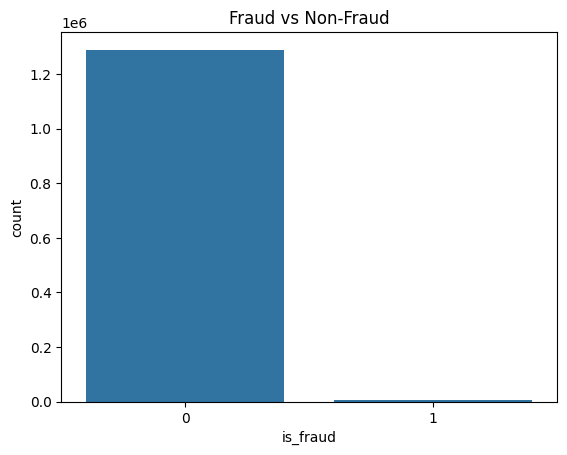

In [72]:
sns.countplot(x=y_train)
plt.title("Fraud vs Non-Fraud")
plt.show()

> ##**Fraud vs Non-Fraud Distribution - Insights**
* The dataset is highly imbalanced, with a significantly larger number of non-fraud transactions compared to fraud transactions.
* Fraud transactions represent only a very small percentage of the total dataset, which is common in real-world financial data.
* This class imbalance can negatively affect model performance, causing the model to become biased toward predicting non-fraud transactions.
* To handle this issue, techniques such as resampling, oversampling, undersampling, or class weighting may be applied during model training.

# 2)-Transaction Amount Analysis

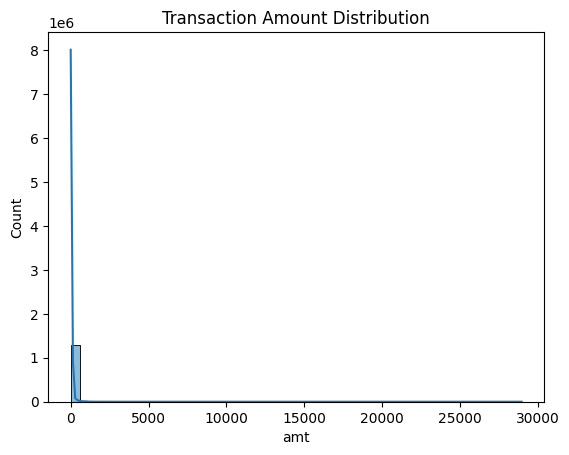

In [73]:
sns.histplot(X_train['amt'], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

##**Transaction Amount Analysis - Insights**

* Fraudulent transactions tend to follow a different distribution compared to non-fraudulent transactions.
* Transactions with higher amounts generally show a greater probability of being fraudulent.
* Most normal transactions are concentrated within lower transaction amount ranges.
* This indicates that transaction amount is an important feature for identifying fraudulent activities.

# 3)-Fraud vs Amount

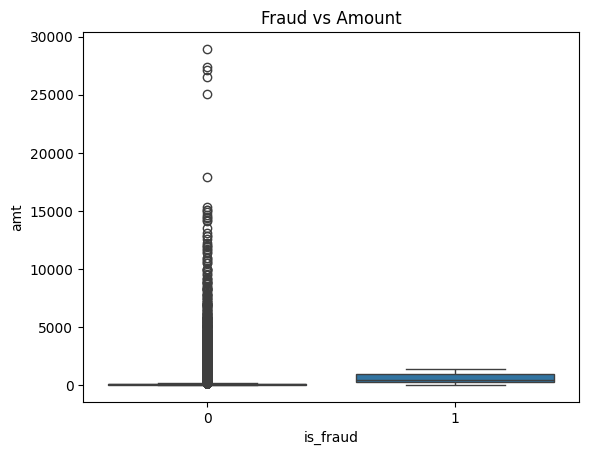

In [74]:
sns.boxplot(x=y_train, y=X_train['amt'])
plt.title("Fraud vs Amount")
plt.show()

##**Transaction Amount vs Fraud (Boxplot) - Insights**
Fraudulent transactions show greater variability in transaction amounts.
The presence of outliers indicates unusual or abnormal transaction behavior.
Non-fraudulent transactions are generally more consistent and concentrated within a smaller range.
Outlier detection can be helpful in identifying potential fraudulent patterns.

# 4)-Time Analysis (Fraud Vs Hour)

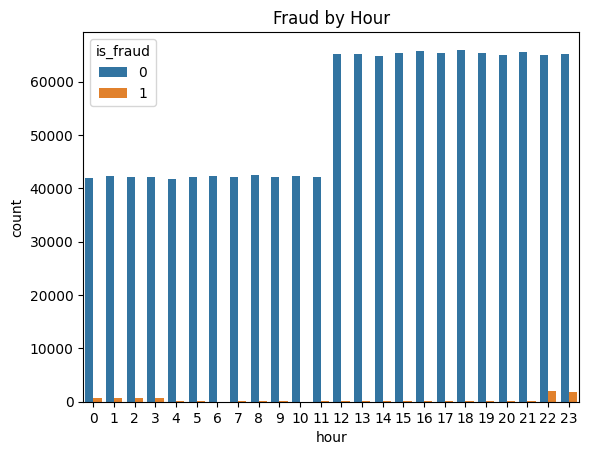

In [75]:
sns.countplot(x=X_train['hour'], hue=y_train)
plt.title("Fraud by Hour")
plt.show()

###**Fraud Distribution by Hour – Insights**

Fraud activity varies significantly across different hours of the day.
Late-night hours show higher fraud activity compared to daytime.
Daytime hours have relatively stable and lower fraud occurrences.
Time-based features can play a crucial role in identifying fraud patterns.

##“Fraudulent transactions are relatively rare across all hours; however, a slight increase is observed during late-night hours (around 22–23), indicating a potentially higher risk during this period.”

# 5)-Category vs Fraud

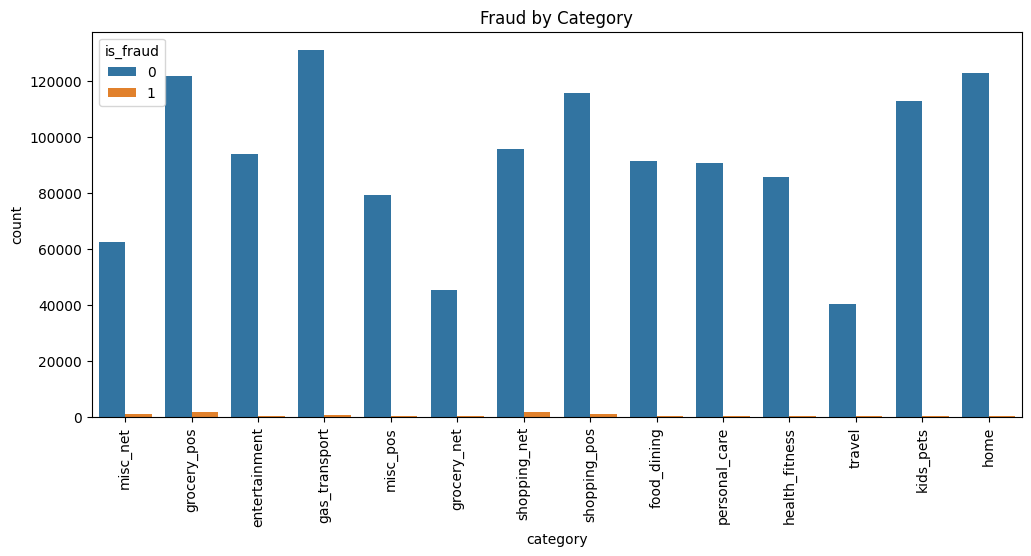

In [76]:
plt.figure(figsize=(12,5))
sns.countplot(x='category', hue='is_fraud', data=train_df)
plt.xticks(rotation=90)
plt.title("Fraud by Category")
plt.show()

##“Fraud is more concentrated in categories such as shopping and grocery transactions, especially in online transactions, indicating a higher risk in these categories.”

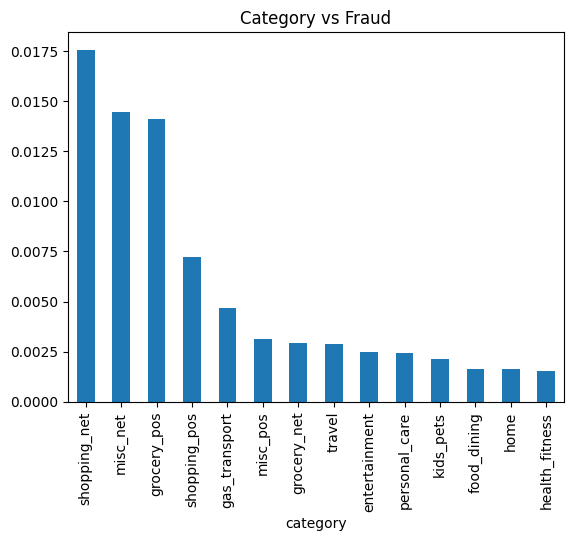

In [77]:
#Analysis
fraud_rate = train_df.groupby('category')['is_fraud'].mean().sort_values(ascending=False)
fraud_rate.plot(kind='bar')
plt.title("Category vs Fraud")
plt.show()

## **Category-wise Fraud Analysis – Insights**
* Certain transaction categories show higher fraud rates than others.
* Fraudsters may target specific types of transactions or merchants.
* This information can help in building category-specific fraud detection rules.

# 6)-Distance vs Fraud

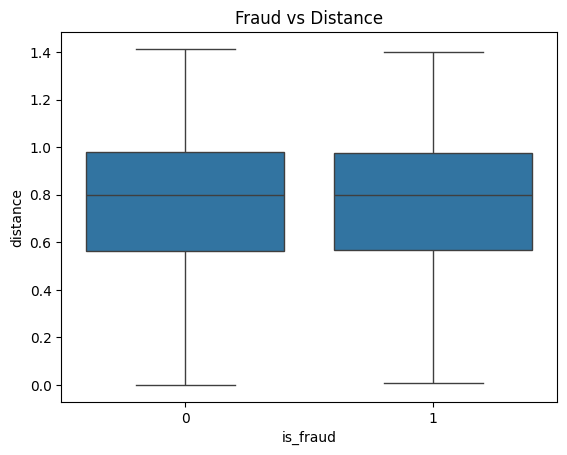

In [78]:
sns.boxplot(x=y_train, y=X_train['distance'])
plt.title("Fraud vs Distance")
plt.show()

##“From the distance pattern, we can conclude that higher transaction distances are associated with a higher chance of fraud, while smaller distances show a lower likelihood of fraud.”

##**Location / Distance Analysis – Insights**
* Fraudulent transactions often occur at unusual or distant locations.
* A large distance between the customer’s location and the transaction location can indicate fraud.
* Location-based features are highly useful in fraud detection.

## 7)-Spike Detection (Time Series)

Text(0.5, 1.0, 'Fraud Transactions Over Time')

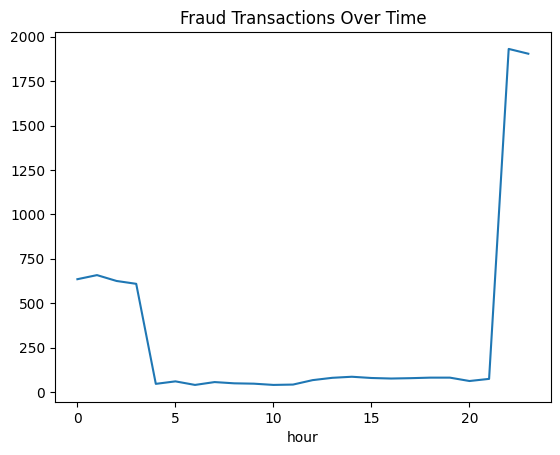

In [79]:
train_df.groupby('hour')['is_fraud'].sum().plot()
plt.title("Fraud Transactions Over Time")

##A significant spike in fraudulent transactions is observed during late-night hours (around 22–23), indicating peak fraudulent activity during this period.
##Fraud activity remains relatively low and stable during daytime but increases sharply at night.
##Early morning hours (0–3) show moderately high fraud activity, though not as extreme as the late-night spike.

## Conclusions
* Fraudulent transactions are very less compared to genuine transactions, showing that the dataset is highly imbalanced.
* Transaction amount (amt) plays an important role in fraud detection, as some fraud cases involve unusually high transaction values.
* Geographic features such as customer and merchant locations are useful for identifying suspicious transactions occurring far from the customer’s usual area.
* Time-related features from unix_time can help detect unusual transaction patterns such as late-night or abnormal activity timings.
* Features like transaction amount, location, and transaction timing are highly beneficial for building accurate fraud detection models
* Proper preprocessing techniques such as feature engineering, handling imbalance, and scaling can significantly improve model performance.